In [1]:
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git

Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163264, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 163264 (delta 16), reused 25 (delta 9), pack-reused 163229 (from 1)
Receiving objects: 100% (163264/163264), 2.00 GiB | 38.42 MiB/s, done.
Resolving deltas: 100% (115/115), done.
Updating files: 100% (182404/182404), done.


In [2]:
import os

print(os.listdir("/content/PlantVillage-Dataset"))

['plant_village.py', '.gitignore', '.git', 'generated_for_paper', 'README.md', 'leaf_grouping', 'CITATION.cff', 'README_HF.md', 'generate_data_for_SVM.py', 'data_distribution_for_SVM', 'generate_lmdb.sh', 'logs', 'leaf-map.json', 'raw', 'scripts', 'utils', 'generate_mapstring.py']


In [3]:
DATA_DIR = "/content/PlantVillage-Dataset/raw/color"

print(os.listdir(DATA_DIR)[:10])

['Tomato___Late_blight', 'Raspberry___healthy', 'Squash___Powdery_mildew', 'Tomato___Bacterial_spot', 'Grape___Black_rot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Apple___Black_rot', 'Grape___healthy', 'Tomato___Target_Spot']


In [4]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
DATA_DIR = "/content/PlantVillage-Dataset/raw/color"

print("Number of classes:", len(os.listdir(DATA_DIR)))
print(os.listdir(DATA_DIR)[:10])

Number of classes: 38
['Tomato___Late_blight', 'Raspberry___healthy', 'Squash___Powdery_mildew', 'Tomato___Bacterial_spot', 'Grape___Black_rot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Apple___Black_rot', 'Grape___healthy', 'Tomato___Target_Spot']


In [6]:
import os
import pandas as pd

classes = sorted(os.listdir(DATA_DIR))

print("Total classes:", len(classes))

for i, class_name in enumerate(classes):
    print(i, class_name)

Total classes: 38
0 Apple___Apple_scab
1 Apple___Black_rot
2 Apple___Cedar_apple_rust
3 Apple___healthy
4 Blueberry___healthy
5 Cherry_(including_sour)___Powdery_mildew
6 Cherry_(including_sour)___healthy
7 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 Corn_(maize)___Common_rust_
9 Corn_(maize)___Northern_Leaf_Blight
10 Corn_(maize)___healthy
11 Grape___Black_rot
12 Grape___Esca_(Black_Measles)
13 Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 Grape___healthy
15 Orange___Haunglongbing_(Citrus_greening)
16 Peach___Bacterial_spot
17 Peach___healthy
18 Pepper,_bell___Bacterial_spot
19 Pepper,_bell___healthy
20 Potato___Early_blight
21 Potato___Late_blight
22 Potato___healthy
23 Raspberry___healthy
24 Soybean___healthy
25 Squash___Powdery_mildew
26 Strawberry___Leaf_scorch
27 Strawberry___healthy
28 Tomato___Bacterial_spot
29 Tomato___Early_blight
30 Tomato___Late_blight
31 Tomato___Leaf_Mold
32 Tomato___Septoria_leaf_spot
33 Tomato___Spider_mites Two-spotted_spider_mite
34 Tomato___

In [7]:
class_counts = {}

for class_name in classes:
    class_path = os.path.join(DATA_DIR, class_name)
    class_counts[class_name] = len(os.listdir(class_path))

class_counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Images"]
)

class_counts_df

,Class,Images
0,Apple___Apple_scab,630
1,Apple___Black_rot,621
2,Apple___Cedar_apple_rust,275
3,Apple___healthy,1645
4,Blueberry___healthy,1502
5,Cherry_(including_sour)___Powdery_mildew,1052
6,Cherry_(including_sour)___healthy,854
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,513
8,Corn_(maize)___Common_rust_,1192
9,Corn_(maize)___Northern_Leaf_Blight,985


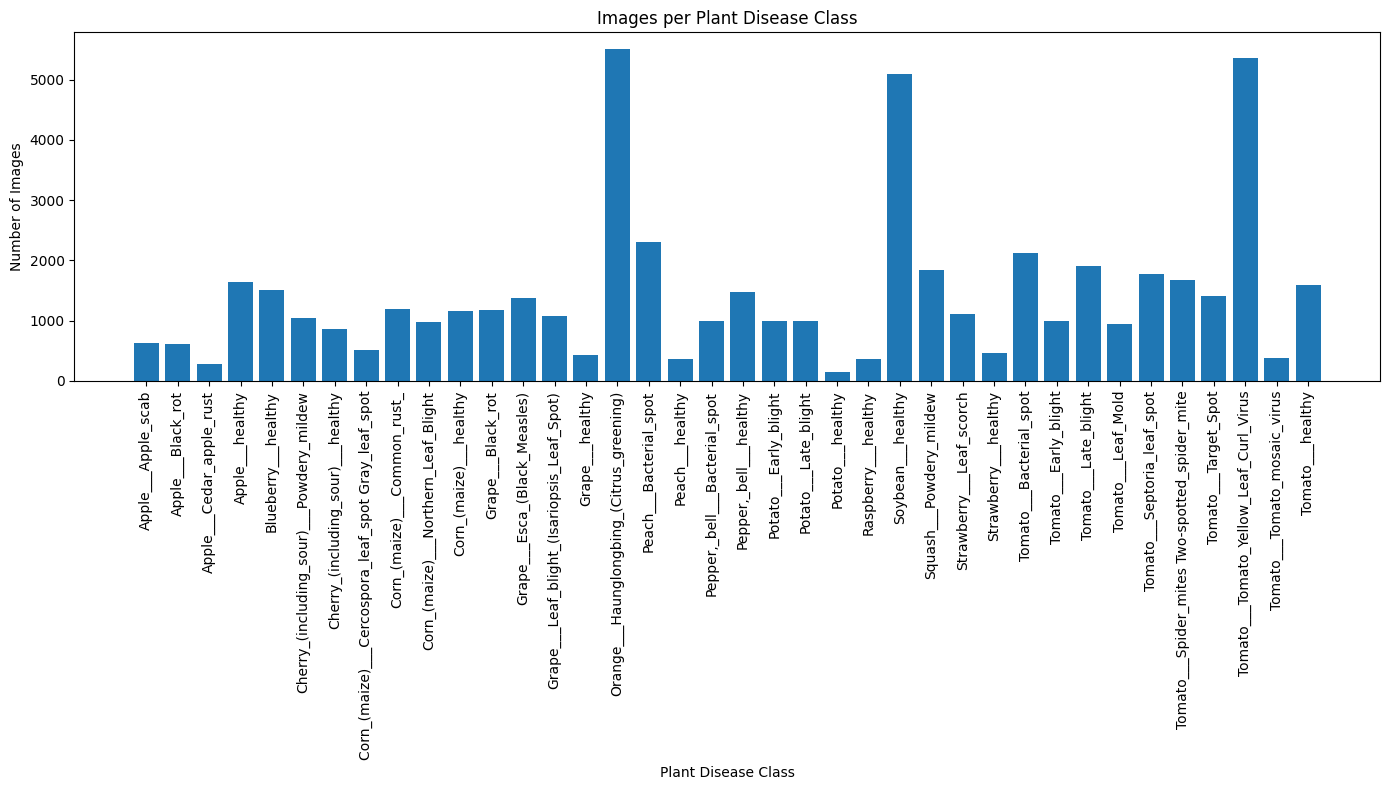

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

plt.bar(
    class_counts_df["Class"],
    class_counts_df["Images"]
)

plt.xticks(rotation=90)
plt.xlabel("Plant Disease Class")
plt.ylabel("Number of Images")
plt.title("Images per Plant Disease Class")
plt.tight_layout()
plt.show()

In [9]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 54305 files belonging to 38 classes.
Using 38014 files for training.


In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 54305 files belonging to 38 classes.
Using 38014 files for training.
Found 54305 files belonging to 38 classes.
Using 16291 files for validation.


In [11]:
class_names = train_ds.class_names

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite

In [12]:
temp_batches = tf.data.experimental.cardinality(temp_ds).numpy()

val_batches = temp_batches // 2

val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Validation batches: 255
Test batches: 255


In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [14]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

In [15]:
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Rescaling(1./127.5, offset=-1),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.2),

    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 93s 70ms/step - accuracy: 0.7889 - loss: 0.7141 - val_accuracy: 0.9140 - val_loss: 0.2668 - learning_rate: 0.0010
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 145s 77ms/step - accuracy: 0.8785 - loss: 0.3678 - val_accuracy: 0.9292 - val_loss: 0.2092 - learning_rate: 0.0010
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 86s 72ms/step - accuracy: 0.8916 - loss: 0.3291 - val_accuracy: 0.9278 - val_loss: 0.2159 - learning_rate: 0.0010
Epoch 4/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 142s 72ms/step - accuracy: 0.9000 - loss: 0.3032 - val_accuracy: 0.9396 - val_loss: 0.1879 - learning_rate: 0.0010
Epoch 5/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 85s 71ms/step - accuracy: 0.9033 - loss: 0.2926 - val_accuracy: 0.9414 - val_loss: 0.1774 - learning_rate: 0.0010
Epoch 6/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 144s 73ms/step - accuracy: 0.9064 - loss: 0.2849 - val_accuracy: 0.9440 - val_loss: 0.1766 - learning_rate: 0.0010
Epoch 7/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 85s 72ms/step - acc

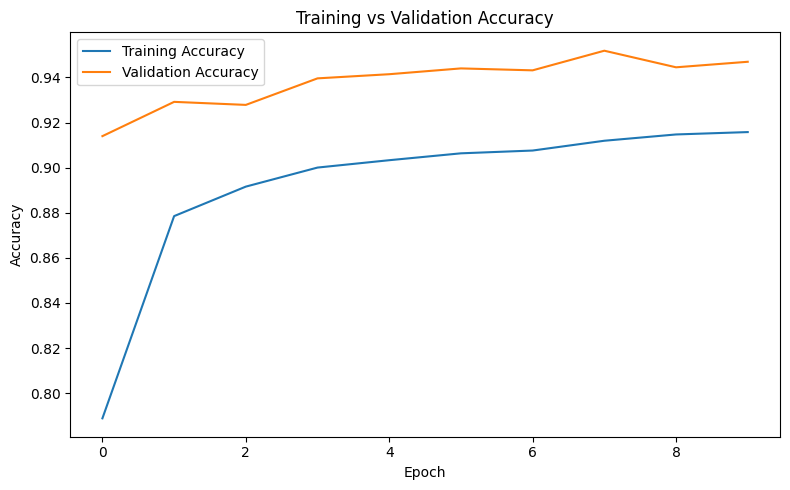

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

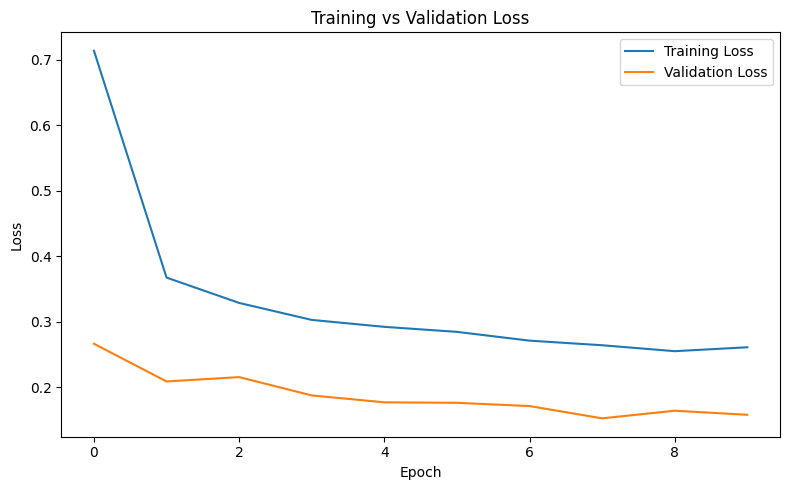

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

255/255 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.9504 - loss: 0.1557
Test Loss: 0.15565751492977142
Test Accuracy: 0.9504365921020508


In [23]:
import numpy as np

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))
    y_prob.extend(np.max(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

In [24]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Apple___Apple_scab,0.922222,0.892473,0.907104,93.000000
Apple___Black_rot,0.960396,0.979798,0.970000,99.000000
Apple___Cedar_apple_rust,0.800000,1.000000,0.888889,40.000000
Apple___healthy,0.968750,1.000000,0.984127,248.000000
Blueberry___healthy,1.000000,0.990826,0.995392,218.000000
Cherry_(including_sour)___Powdery_mildew,1.000000,0.945055,0.971751,182.000000
Cherry_(including_sour)___healthy,0.962963,1.000000,0.981132,130.000000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.904110,0.785714,0.840764,84.000000
Corn_(maize)___Common_rust_,0.981818,0.993865,0.987805,163.000000
Corn_(maize)___Northern_Leaf_Blight,0.891892,0.956522,0.923077,138.000000


In [25]:
os.makedirs("results", exist_ok=True)

report_df.to_csv(
    "results/classification_report.csv"
)

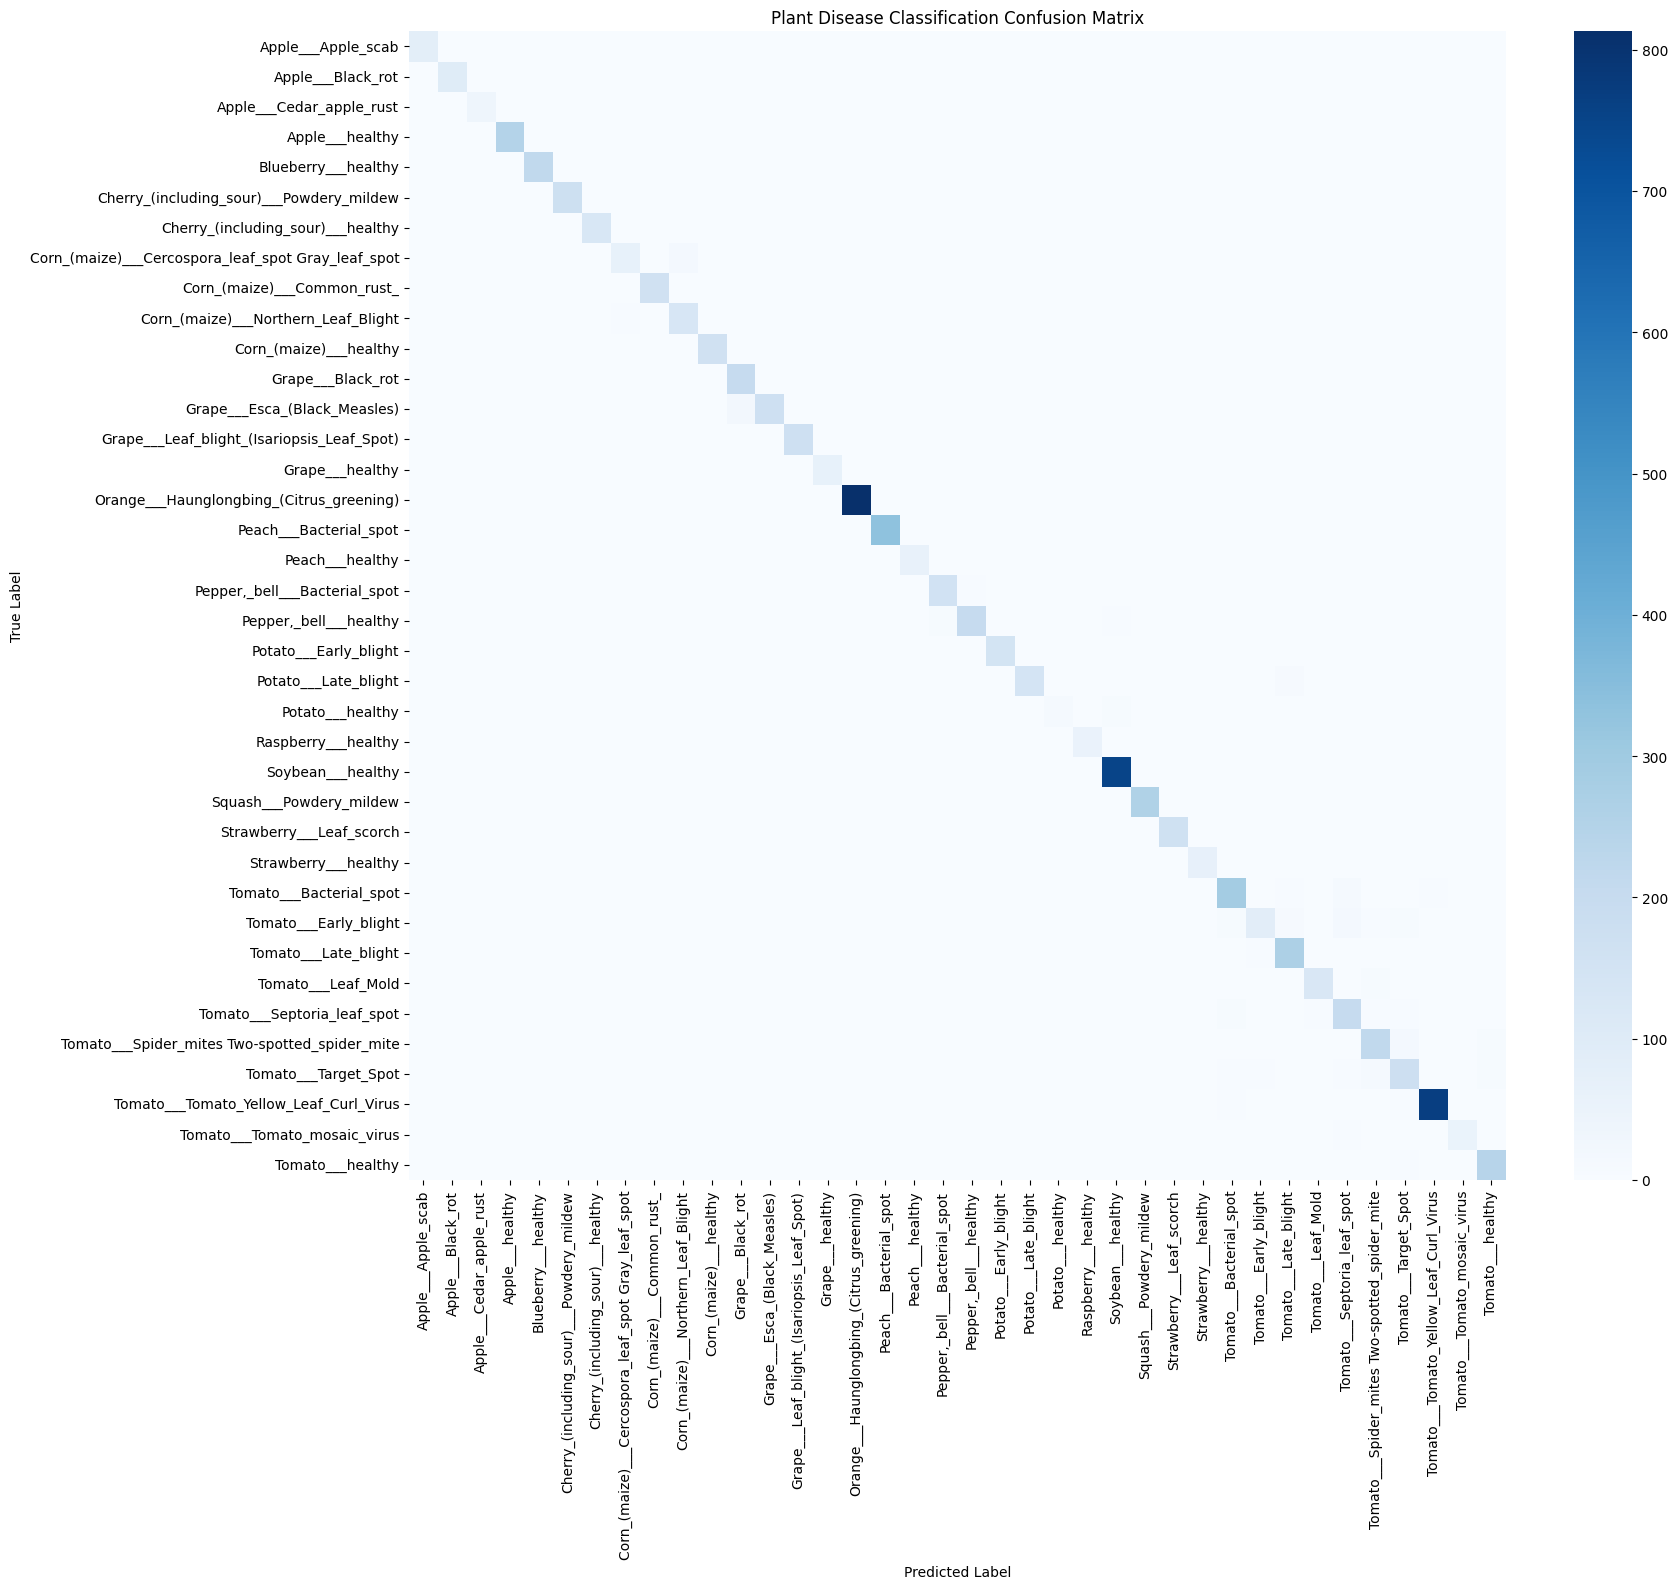

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 16))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Plant Disease Classification Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "results/confusion_matrix.png",
    dpi=300
)

plt.show()

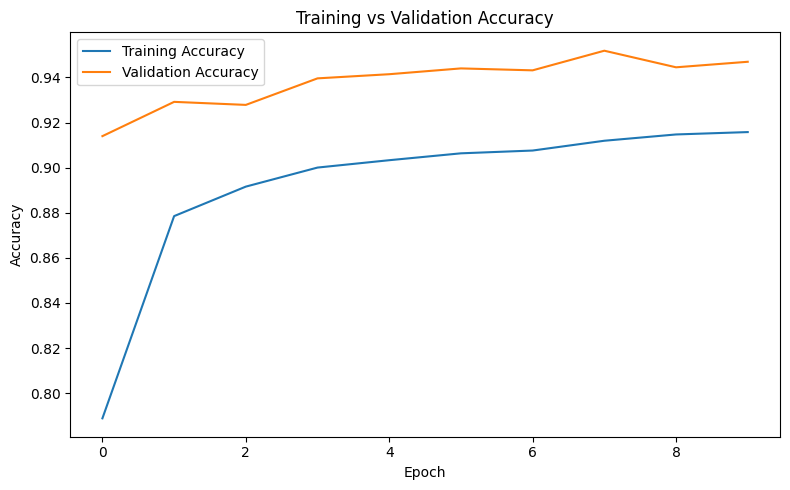

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()

plt.savefig(
    "results/training_validation_accuracy.png",
    dpi=300
)

plt.show()

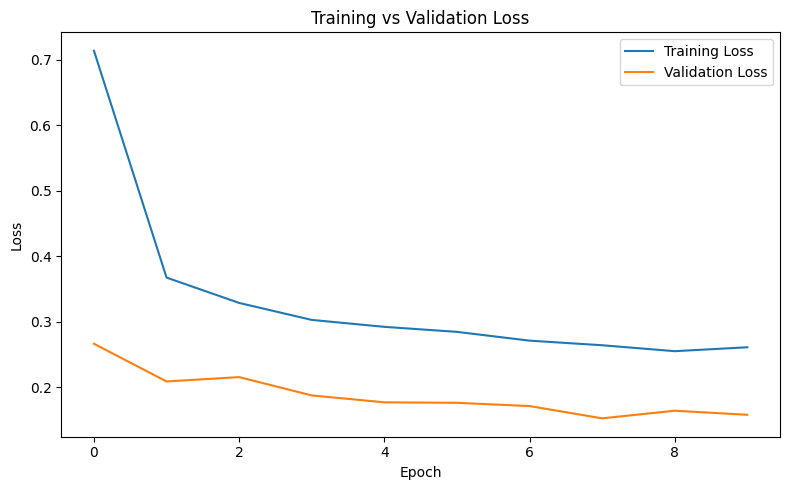

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    "results/training_validation_loss.png",
    dpi=300
)

plt.show()

In [29]:
model.save("plant_disease_model.keras")

In [30]:
os.path.getsize("plant_disease_model.keras") / (1024 * 1024)

11.126016616821289

In [31]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

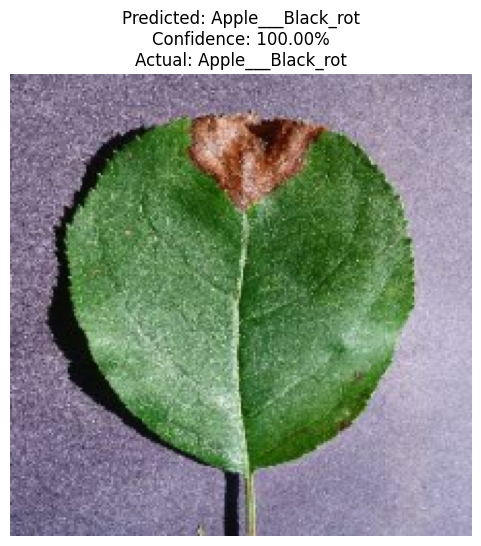

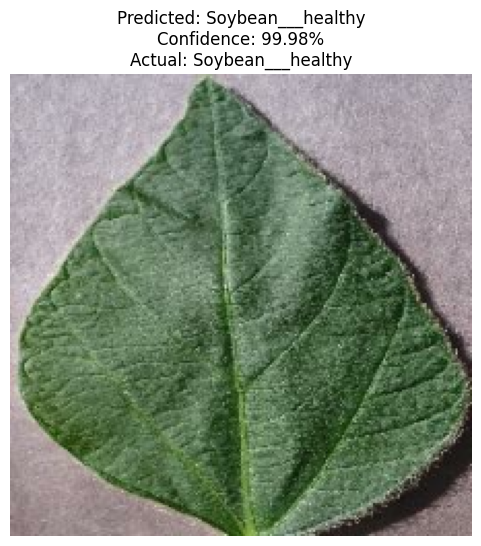

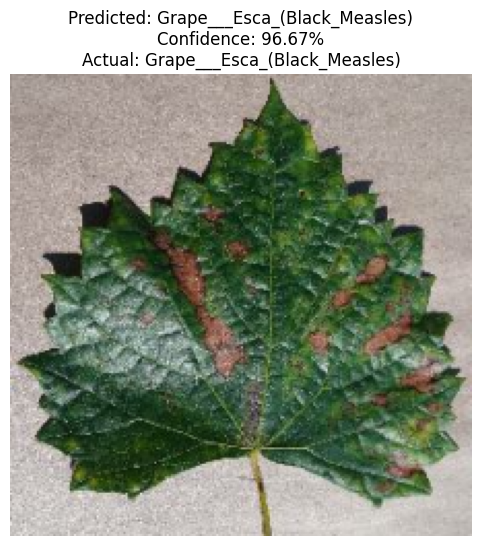

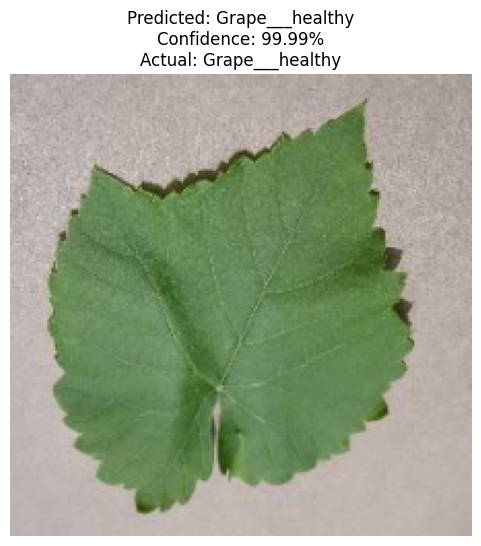

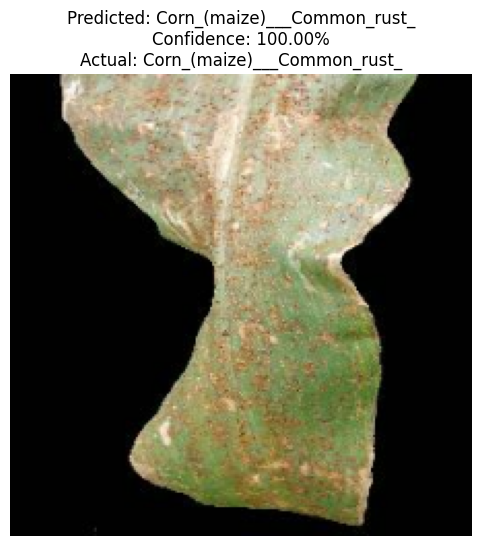

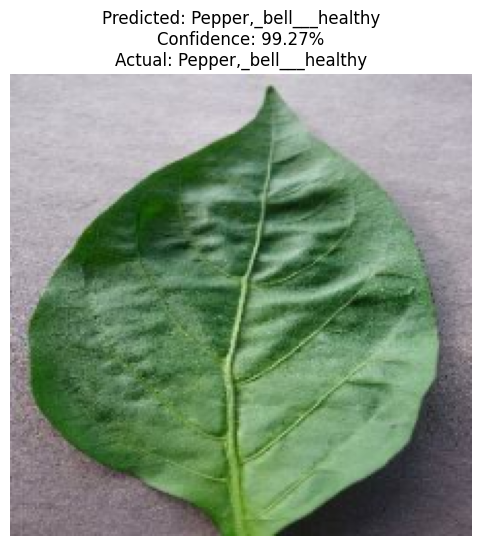

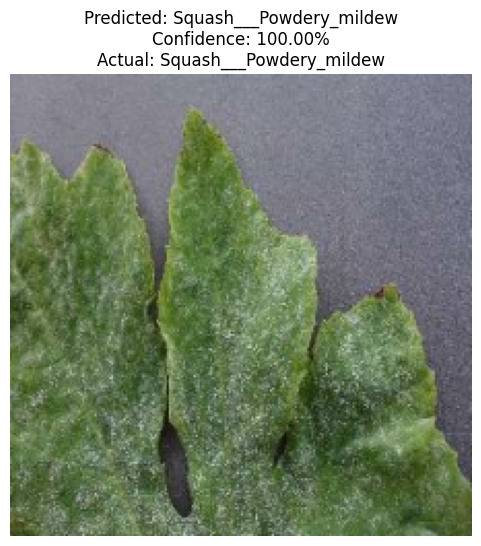

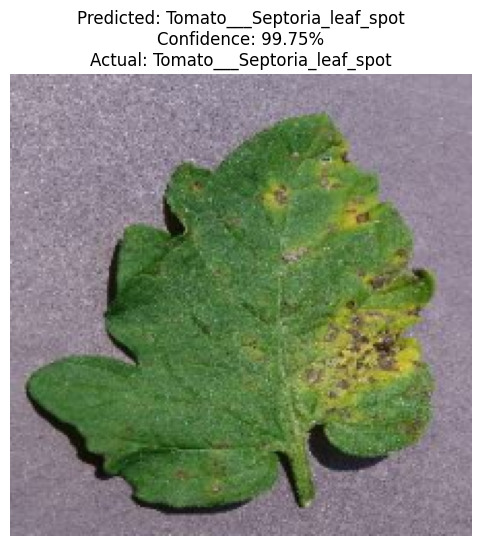

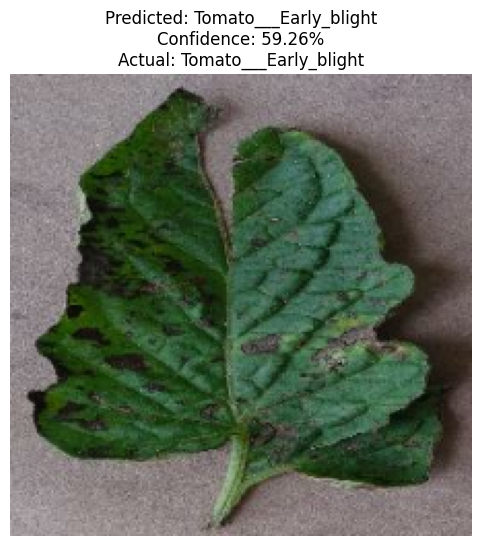

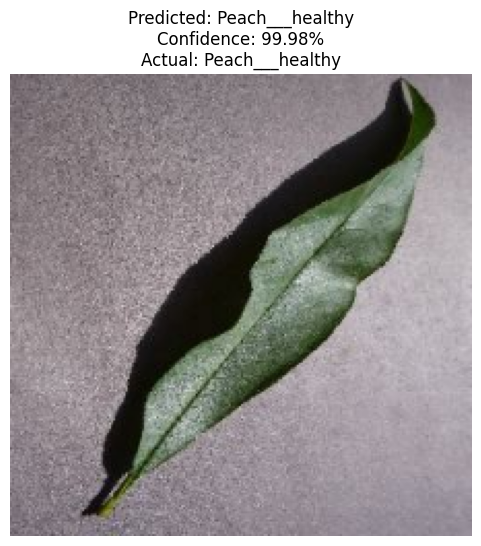

In [32]:
os.makedirs("results/inference_samples", exist_ok=True)

sample_count = 0

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    for i in range(len(images)):

        if sample_count >= 10:
            break

        predicted_index = np.argmax(predictions[i])
        confidence = np.max(predictions[i])

        true_label = class_names[labels[i].numpy()]
        predicted_label = class_names[predicted_index]

        plt.figure(figsize=(6, 6))

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(
            f"Predicted: {predicted_label}\n"
            f"Confidence: {confidence:.2%}\n"
            f"Actual: {true_label}"
        )

        plt.axis("off")

        filename = (
            f"results/inference_samples/"
            f"sample_{sample_count+1}.png"
        )

        plt.savefig(
            filename,
            dpi=150,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

        sample_count += 1

    if sample_count >= 10:
        break

In [33]:
from tensorflow.keras.utils import load_img, img_to_array

def predict_plant_disease(image_path):

    image = load_img(
        image_path,
        target_size=(224, 224)
    )

    image_array = img_to_array(image)

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    predictions = model.predict(
        image_array,
        verbose=0
    )[0]

    predicted_index = np.argmax(predictions)

    predicted_class = class_names[predicted_index]

    confidence = predictions[predicted_index]

    print("Predicted Disease:", predicted_class)
    print("Confidence:", f"{confidence:.2%}")

    return predicted_class, confidence

In [35]:
predict_plant_disease(
    "your_image.jpg"
)

Predicted Disease: Strawberry___Leaf_scorch
Confidence: 70.60%


('Strawberry___Leaf_scorch', np.float32(0.7059776))